# So sánh 3 mô hình: CNN, MobileNetV2, ResNet50

In [1]:
import os
import re
import glob
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings("ignore")

In [2]:
RESNET_DIR = r"C:\Users\dungt\Downloads\BCKLTN\resnet50_output"
MOBILENET_DIR = r"C:\Users\dungt\Downloads\BCKLTN\mobilenetv2_output"
CNN_DIR = r"C:\Users\dungt\Downloads\BCKLTN\CNN-output"

MODEL_DIRS = {
    "CNN": CNN_DIR,
    "MobileNetV2": MOBILENET_DIR,
    "ResNet50": RESNET_DIR
}

CLASS_NAMES = ["bad", "good", "shell"]

OUTPUT_DIR = r"C:\Users\dungt\Downloads\BCKLTN\model_comparison_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Thư mục lưu kết quả so sánh:")
print(OUTPUT_DIR)

Thư mục lưu kết quả so sánh:
C:\Users\dungt\Downloads\BCKLTN\model_comparison_output


In [3]:
for model_name, folder in MODEL_DIRS.items():
    print(f"{model_name}: {folder}")
    print("  -> Tồn tại" if os.path.exists(folder) else "  -> KHÔNG tìm thấy")

CNN: C:\Users\dungt\Downloads\BCKLTN\CNN-output
  -> Tồn tại
MobileNetV2: C:\Users\dungt\Downloads\BCKLTN\mobilenetv2_output
  -> Tồn tại
ResNet50: C:\Users\dungt\Downloads\BCKLTN\resnet50_output
  -> Tồn tại


In [4]:
def find_files(folder, extensions):
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder, "**", f"*{ext}"), recursive=True))
    return files


def normalize_label(x):
    if pd.isna(x):
        return x

    x_str = str(x).strip()

    if x_str.isdigit():
        idx = int(x_str)
        if 0 <= idx < len(CLASS_NAMES):
            return CLASS_NAMES[idx]

    x_low = x_str.lower()
    for class_name in CLASS_NAMES:
        if x_low == class_name.lower():
            return class_name

    return x_str


def find_prediction_csv(folder):
    csv_files = find_files(folder, [".csv"])

    priority_keywords = [
        "test_predictions", "predictions", "prediction",
        "test_result", "test_results", "result", "results"
    ]

    sorted_files = sorted(
        csv_files,
        key=lambda x: (
            not any(k in os.path.basename(x).lower() for k in priority_keywords),
            len(os.path.basename(x))
        )
    )

    actual_candidates = ["actual", "true", "y_true", "label", "real_label", "actual_label", "ground_truth"]
    pred_candidates = ["predicted", "prediction", "y_pred", "pred", "pred_label", "predicted_label"]

    for file_path in sorted_files:
        try:
            df = pd.read_csv(file_path)
            cols = [str(c).strip().lower() for c in df.columns]
            has_actual = any(c in cols for c in actual_candidates)
            has_pred = any(c in cols for c in pred_candidates)

            if has_actual and has_pred:
                return file_path
        except Exception:
            pass

    return None


def read_prediction_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip().lower() for c in df.columns]

    actual_candidates = ["actual", "true", "y_true", "label", "real_label", "actual_label", "ground_truth"]
    pred_candidates = ["predicted", "prediction", "y_pred", "pred", "pred_label", "predicted_label"]

    actual_col = next((c for c in actual_candidates if c in df.columns), None)
    pred_col = next((c for c in pred_candidates if c in df.columns), None)

    if actual_col is None or pred_col is None:
        raise ValueError(f"Không tìm thấy cột nhãn thật/dự đoán trong file: {csv_path}")

    y_true = df[actual_col].apply(normalize_label).values
    y_pred = df[pred_col].apply(normalize_label).values

    return y_true, y_pred, df

In [5]:
def find_report_txt(folder):
    txt_files = find_files(folder, [".txt"])
    keywords = ["classification_report", "report", "metric", "metrics", "evaluation"]

    sorted_files = sorted(
        txt_files,
        key=lambda x: (
            not any(k in os.path.basename(x).lower() for k in keywords),
            len(os.path.basename(x))
        )
    )

    for file_path in sorted_files:
        try:
            text = Path(file_path).read_text(encoding="utf-8", errors="ignore")
            text_low = text.lower()
            if "precision" in text_low and "recall" in text_low and "f1" in text_low:
                return file_path
        except Exception:
            pass

    return None


def parse_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def parse_classification_report_txt(report_path, model_name):
    text = Path(report_path).read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    summary = {
        "model": model_name,
        "source": report_path,
        "accuracy": np.nan,
        "precision_macro": np.nan,
        "recall_macro": np.nan,
        "f1_macro": np.nan,
        "precision_weighted": np.nan,
        "recall_weighted": np.nan,
        "f1_weighted": np.nan,
        "support": np.nan
    }

    per_class_rows = []

    for line in lines:
        clean = line.strip()
        if not clean:
            continue

        if clean.startswith("accuracy"):
            nums = re.findall(r"\d+\.\d+|\d+", clean)
            if len(nums) >= 1:
                summary["accuracy"] = parse_float(nums[0])
            if len(nums) >= 2:
                summary["support"] = parse_float(nums[-1])

        elif clean.startswith("macro avg"):
            nums = re.findall(r"\d+\.\d+|\d+", clean)
            if len(nums) >= 4:
                summary["precision_macro"] = parse_float(nums[0])
                summary["recall_macro"] = parse_float(nums[1])
                summary["f1_macro"] = parse_float(nums[2])
                summary["support"] = parse_float(nums[3])

        elif clean.startswith("weighted avg"):
            nums = re.findall(r"\d+\.\d+|\d+", clean)
            if len(nums) >= 4:
                summary["precision_weighted"] = parse_float(nums[0])
                summary["recall_weighted"] = parse_float(nums[1])
                summary["f1_weighted"] = parse_float(nums[2])

        else:
            parts = clean.split()
            label = parts[0] if parts else ""
            if label in CLASS_NAMES:
                nums = re.findall(r"\d+\.\d+|\d+", clean)
                if len(nums) >= 4:
                    per_class_rows.append({
                        "model": model_name,
                        "class": label,
                        "precision": parse_float(nums[0]),
                        "recall": parse_float(nums[1]),
                        "f1_score": parse_float(nums[2]),
                        "support": parse_float(nums[3])
                    })

    return summary, per_class_rows

In [6]:
def calculate_metrics_from_predictions(y_true, y_pred, model_name, source_path):
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    summary = {
        "model": model_name,
        "source": source_path,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted": report["weighted avg"]["recall"],
        "f1_weighted": report["weighted avg"]["f1-score"],
        "support": report["macro avg"]["support"]
    }

    per_class_rows = []

    for class_name in CLASS_NAMES:
        per_class_rows.append({
            "model": model_name,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": report[class_name]["support"]
        })

    return summary, per_class_rows

In [7]:
summary_rows = []
per_class_rows_all = []
used_files = []

for model_name, folder in MODEL_DIRS.items():
    if not os.path.exists(folder):
        print(f"Không tìm thấy thư mục: {folder}")
        continue

    pred_csv = find_prediction_csv(folder)

    if pred_csv is not None:
        y_true, y_pred, pred_df = read_prediction_csv(pred_csv)
        summary, per_class_rows = calculate_metrics_from_predictions(
            y_true, y_pred, model_name, pred_csv
        )
        print(f"{model_name}: đọc từ file dự đoán CSV")
        print(pred_csv)
    else:
        report_txt = find_report_txt(folder)
        if report_txt is None:
            print(f"{model_name}: không tìm thấy CSV dự đoán hoặc classification report")
            continue

        summary, per_class_rows = parse_classification_report_txt(report_txt, model_name)
        print(f"{model_name}: đọc từ classification report TXT")
        print(report_txt)

    summary_rows.append(summary)
    per_class_rows_all.extend(per_class_rows)
    used_files.append({"model": model_name, "file": summary["source"]})

summary_df = pd.DataFrame(summary_rows)
per_class_df = pd.DataFrame(per_class_rows_all)
used_files_df = pd.DataFrame(used_files)

summary_df

CNN: đọc từ file dự đoán CSV
C:\Users\dungt\Downloads\BCKLTN\CNN-output\CNN_test_predictions.csv
MobileNetV2: đọc từ classification report TXT
C:\Users\dungt\Downloads\BCKLTN\mobilenetv2_output\mobilenetv2_classification_report_val.txt
ResNet50: đọc từ classification report TXT
C:\Users\dungt\Downloads\BCKLTN\resnet50_output\resnet50_classification_report_val.txt


,model,source,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,support
0,CNN,C:\Users\dungt\Downloads\BCKLTN\CNN-output\CNN...,0.9772,0.976351,0.977207,0.976605,0.977766,0.9772,0.977317,1886.0
1,MobileNetV2,C:\Users\dungt\Downloads\BCKLTN\mobilenetv2_ou...,0.9742,0.972900,0.968200,0.970300,0.974800,0.9742,0.974300,2990.0
2,ResNet50,C:\Users\dungt\Downloads\BCKLTN\resnet50_outpu...,0.9967,0.996300,0.995900,0.996100,0.996700,0.9967,0.996700,2990.0


In [8]:
if summary_df.empty:
    raise ValueError("Chưa đọc được kết quả model nào. Hãy kiểm tra lại 3 thư mục output.")

summary_df = summary_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

summary_path = os.path.join(OUTPUT_DIR, "model_comparison_summary.csv")
per_class_path = os.path.join(OUTPUT_DIR, "model_comparison_per_class.csv")
used_files_path = os.path.join(OUTPUT_DIR, "used_result_files.csv")

summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
per_class_df.to_csv(per_class_path, index=False, encoding="utf-8-sig")
used_files_df.to_csv(used_files_path, index=False, encoding="utf-8-sig")

display(summary_df)
display(per_class_df)

,model,source,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,support
0,ResNet50,C:\Users\dungt\Downloads\BCKLTN\resnet50_outpu...,0.9967,0.996300,0.995900,0.996100,0.996700,0.9967,0.996700,2990.0
1,CNN,C:\Users\dungt\Downloads\BCKLTN\CNN-output\CNN...,0.9772,0.976351,0.977207,0.976605,0.977766,0.9772,0.977317,1886.0
2,MobileNetV2,C:\Users\dungt\Downloads\BCKLTN\mobilenetv2_ou...,0.9742,0.972900,0.968200,0.970300,0.974800,0.9742,0.974300,2990.0


,model,class,precision,recall,f1_score,support
0,CNN,bad,0.945183,0.982729,0.963590,579.0
1,CNN,good,0.983871,0.965190,0.974441,632.0
2,CNN,shell,1.000000,0.983704,0.991785,675.0
3,MobileNetV2,bad,0.937300,0.970600,0.953600,816.0
4,MobileNetV2,good,0.986500,0.987100,0.986800,1551.0
5,MobileNetV2,shell,0.994900,0.947000,0.970400,623.0
6,ResNet50,bad,0.990300,0.997500,0.993900,816.0
7,ResNet50,good,0.998700,0.998100,0.998400,1551.0
8,ResNet50,shell,1.000000,0.992000,0.996000,623.0


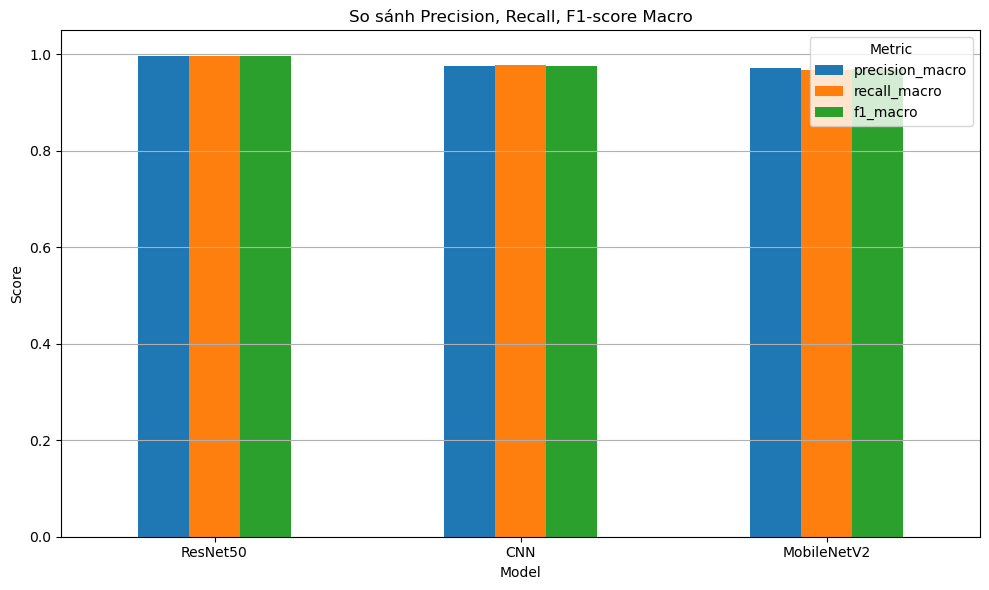

In [9]:
plot_df = summary_df.set_index("model")[["precision_macro", "recall_macro", "f1_macro"]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("So sánh Precision, Recall, F1-score Macro")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric")
plt.tight_layout()

macro_chart_path = os.path.join(OUTPUT_DIR, "macro_metrics_comparison.png")
plt.savefig(macro_chart_path, dpi=300, bbox_inches="tight")
plt.show()

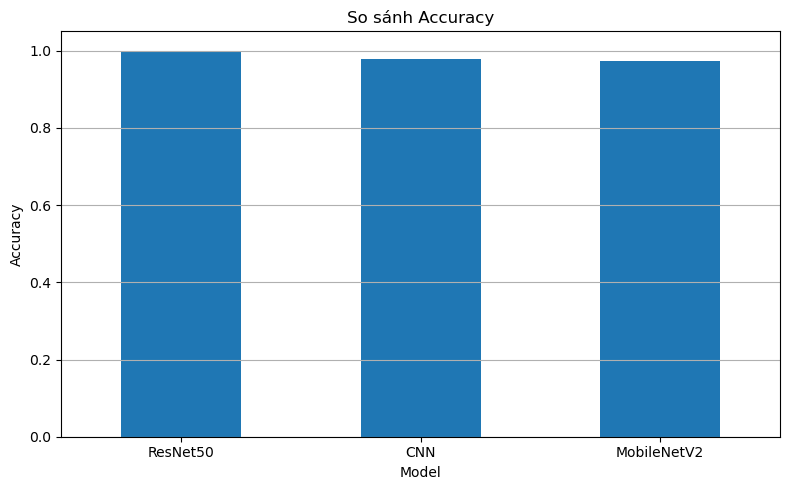

In [10]:
accuracy_df = summary_df.set_index("model")[["accuracy"]]

accuracy_df.plot(kind="bar", figsize=(8, 5), legend=False)
plt.title("So sánh Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

accuracy_chart_path = os.path.join(OUTPUT_DIR, "accuracy_comparison.png")
plt.savefig(accuracy_chart_path, dpi=300, bbox_inches="tight")
plt.show()

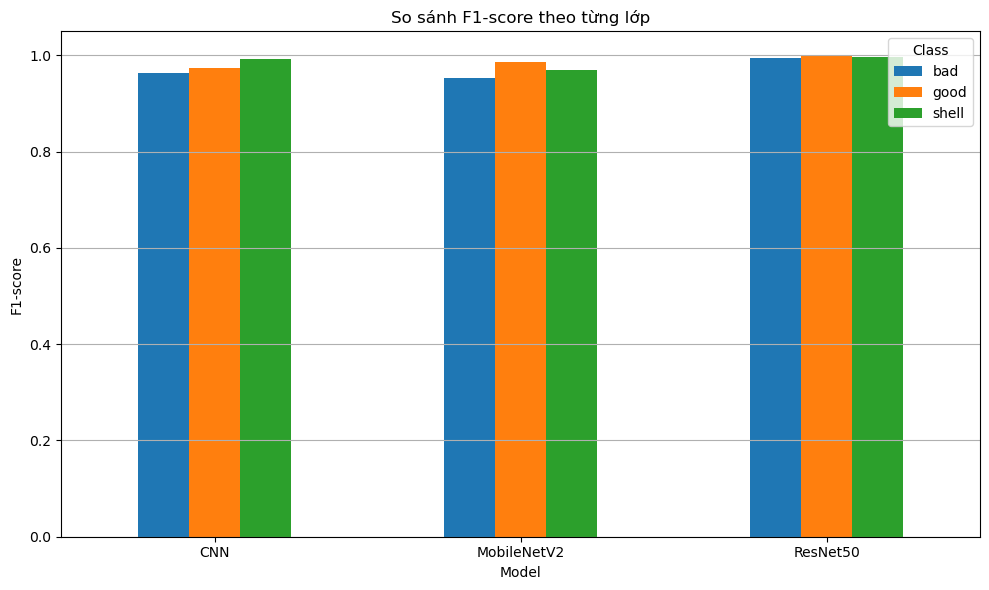

In [11]:
if not per_class_df.empty:
    f1_class_df = per_class_df.pivot(index="model", columns="class", values="f1_score")

    f1_class_df.plot(kind="bar", figsize=(10, 6))
    plt.title("So sánh F1-score theo từng lớp")
    plt.xlabel("Model")
    plt.ylabel("F1-score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.legend(title="Class")
    plt.tight_layout()

    f1_class_chart_path = os.path.join(OUTPUT_DIR, "f1_score_per_class_comparison.png")
    plt.savefig(f1_class_chart_path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Không có dữ liệu per-class để vẽ biểu đồ.")

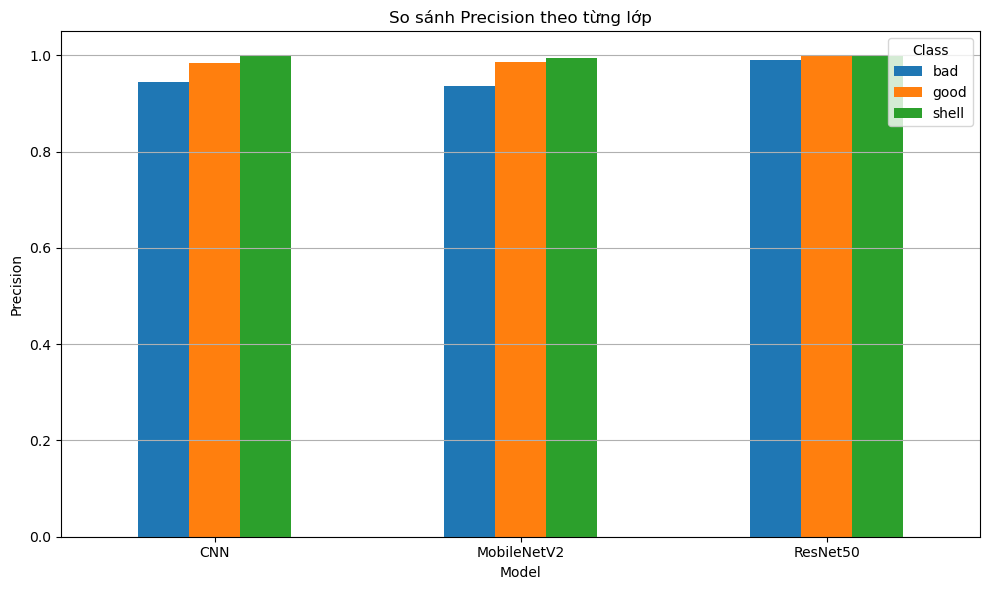

In [12]:
if not per_class_df.empty:
    precision_class_df = per_class_df.pivot(index="model", columns="class", values="precision")

    precision_class_df.plot(kind="bar", figsize=(10, 6))
    plt.title("So sánh Precision theo từng lớp")
    plt.xlabel("Model")
    plt.ylabel("Precision")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.legend(title="Class")
    plt.tight_layout()

    precision_class_chart_path = os.path.join(OUTPUT_DIR, "precision_per_class_comparison.png")
    plt.savefig(precision_class_chart_path, dpi=300, bbox_inches="tight")
    plt.show()

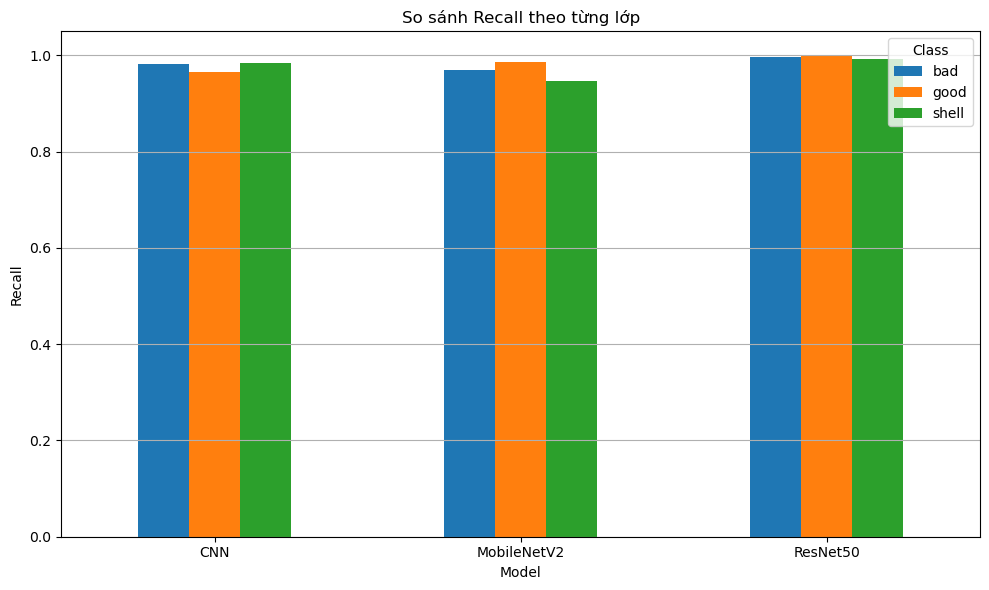

In [13]:
if not per_class_df.empty:
    recall_class_df = per_class_df.pivot(index="model", columns="class", values="recall")

    recall_class_df.plot(kind="bar", figsize=(10, 6))
    plt.title("So sánh Recall theo từng lớp")
    plt.xlabel("Model")
    plt.ylabel("Recall")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.legend(title="Class")
    plt.tight_layout()

    recall_class_chart_path = os.path.join(OUTPUT_DIR, "recall_per_class_comparison.png")
    plt.savefig(recall_class_chart_path, dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
best_row = summary_df.iloc[0]
best_model = best_row["model"]
best_f1 = best_row["f1_macro"]

conclusion = f'''KẾT QUẢ SO SÁNH 3 MÔ HÌNH

Mô hình có F1-score macro cao nhất: {best_model}
F1-score macro: {best_f1:.4f}

Trong bài toán phân loại trứng tằm gồm 3 lớp bad, good và shell, F1-score macro là chỉ số quan trọng vì đánh giá trung bình hiệu quả trên từng lớp. Chỉ số này phù hợp khi dữ liệu có khả năng mất cân bằng giữa các lớp.

Các file kết quả đã lưu trong thư mục:
{OUTPUT_DIR}
'''

conclusion_path = os.path.join(OUTPUT_DIR, "comparison_conclusion.txt")

with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion)

print(conclusion)

KẾT QUẢ SO SÁNH 3 MÔ HÌNH

Mô hình có F1-score macro cao nhất: ResNet50
F1-score macro: 0.9961

Trong bài toán phân loại trứng tằm gồm 3 lớp bad, good và shell, F1-score macro là chỉ số quan trọng vì đánh giá trung bình hiệu quả trên từng lớp. Chỉ số này phù hợp khi dữ liệu có khả năng mất cân bằng giữa các lớp.

Các file kết quả đã lưu trong thư mục:
C:\Users\dungt\Downloads\BCKLTN\model_comparison_output



In [15]:
zip_base = r"C:\Users\dungt\Downloads\BCKLTN\model_comparison_output"
zip_path = zip_base + ".zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_base, "zip", OUTPUT_DIR)

print("Đã tạo file zip:")
print(zip_path)

Đã tạo file zip:
C:\Users\dungt\Downloads\BCKLTN\model_comparison_output.zip


Sau khi chạy xong, file zip nằm tại:

`C:\Users\dungt\Downloads\BCKLTN\model_comparison_output.zip`